# AdaFTRL-V2 Censor-Only Stress Test

This notebook creates a deliberately harsh stream. The first 299 rounds are ordinary right-censored data. From round 300 onward, the learner receives only censored observations for a very long horizon: `Delta = 0` on every remaining round.

This is designed to stress the exact ambiguity discussed in `adaftrl_ambiguity_neutral_updated.tex`: the bad information loss is not `Delta = 0` by itself, but the ambiguous region `{Delta = 0, Y < L}`. In this stress test, the censor-only phase mostly creates that ambiguous region.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from online_survival.experiments import (
    SimulationConfig,
    behavior_svg,
    format_markdown_table,
    run_censor_only_stress_experiment,
    summarize_one_run,
)


def show_markdown(markdown):
    try:
        from IPython.display import Markdown, display
        display(Markdown(markdown))
    except Exception:
        print(markdown)


def show_svg(svg):
    try:
        from IPython.display import SVG, display
        display(SVG(svg))
    except Exception:
        print(svg[:1000])

## Stress Setup

The long-horizon part is intentionally extreme: after the switch round, no event is ever observed. Latent event times are still sampled so that we can evaluate realized coverage, but the learner only sees censoring feedback.

In [2]:
censor_only_start = 300

config = SimulationConfig(
    n_rounds=5000,
    alpha=0.10,
    tau_max=0.50,
    eta=0.010,
    model_log_shift=0.30,
    censoring_rate=0.18,
)

config

SimulationConfig(n_rounds=5000, alpha=0.1, tau_max=0.5, eta=0.01, tau_min=1e-06, x_low=-1.0, x_high=1.0, true_intercept=1.0, true_slope=0.35, true_sigma=0.55, model_log_shift=0.3, model_sigma=0.55, censoring_rate=0.18)

## Run The Stress Stream

`AdaFTRL-V2` neutralizes ambiguous censored-below-bound rounds by using feedback value `alpha`, which gives zero internal gradient. The original AdaFTRL and both direct ACI updates keep seeing surrogate error zero during the censor-only phase, so they drift toward larger lower bounds.

In [3]:
records = run_censor_only_stress_experiment(
    config,
    seed=5,
    censor_only_start=censor_only_start,
    forced_censor_fraction=0.20,
    include_adaftrl_v2=True,
)

summary_columns = [
    "algorithm",
    "realized_coverage",
    "target_coverage",
    "coverage_shortfall",
    "coverage_abs_error",
    "average_conditional_coverage",
    "ambiguous_below_bound_fraction",
    "final_tau",
    "censoring_fraction",
]

show_markdown("### Full 5,000-Round Run")
show_markdown(format_markdown_table(summarize_one_run(records), summary_columns, digits=4))

### Full 5,000-Round Run

| algorithm | realized_coverage | target_coverage | coverage_shortfall | coverage_abs_error | average_conditional_coverage | ambiguous_below_bound_fraction | final_tau | censoring_fraction |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ACI with IPCW | 0.3472 | 0.9000 | 0.5528 | 0.5528 | 0.3508 | 0.9548 | 0.5000 | 0.9660 |
| ACI without IPCW | 0.9964 | 0.9000 | 0.0000 | 0.0964 | 0.9954 | 0.5068 | 0.0010 | 0.9660 |
| AdaFTRL | 0.3388 | 0.9000 | 0.5612 | 0.5612 | 0.3419 | 0.9552 | 0.5000 | 0.9660 |
| AdaFTRL-V2 | 0.8956 | 0.9000 | 0.0044 | 0.0044 | 0.8962 | 0.9542 | 0.0351 | 0.9660 |

## Censor-Only Phase

The table below evaluates only rounds 300 through 5000. The censoring fraction is exactly 1.0 there, and the ambiguous-below-bound fraction is also essentially 1.0.

In [4]:
censor_only_records = [row for row in records if row["t"] >= censor_only_start]

show_markdown("### Rounds 300-5000 Only")
show_markdown(format_markdown_table(summarize_one_run(censor_only_records), summary_columns, digits=4))

### Rounds 300-5000 Only

| algorithm | realized_coverage | target_coverage | coverage_shortfall | coverage_abs_error | average_conditional_coverage | ambiguous_below_bound_fraction | final_tau | censoring_fraction |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ACI with IPCW | 0.3138 | 0.9000 | 0.5862 | 0.5862 | 0.3179 | 1.0000 | 0.5000 | 1.0000 |
| ACI without IPCW | 0.9985 | 0.9000 | 0.0000 | 0.0985 | 0.9974 | 0.5292 | 0.0010 | 1.0000 |
| AdaFTRL | 0.3050 | 0.9000 | 0.5950 | 0.5950 | 0.3084 | 1.0000 | 0.5000 | 1.0000 |
| AdaFTRL-V2 | 0.8956 | 0.9000 | 0.0044 | 0.0044 | 0.8971 | 1.0000 | 0.0351 | 1.0000 |

## Behavior Figure

The vertical dashed line marks the start of the censor-only phase. Both panels include axis labels and numeric ticks.

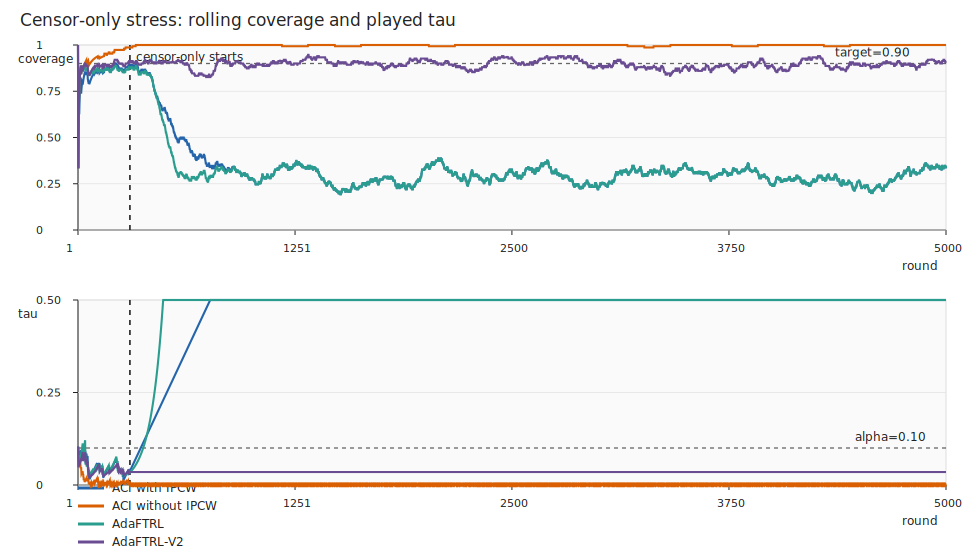

In [5]:
show_svg(
    behavior_svg(
        records,
        window=150,
        phase_change_round=censor_only_start,
        title="Censor-only stress: rolling coverage and played tau",
    )
)